In [7]:
import scipy.io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_folder1 = 'data/battery_dataset/BatteryAgingARC_25_26_27_28_P1'
data_folder2 = 'data/battery_dataset/BatteryAgingARC_25-44'
data_folder3 = 'data/battery_dataset/BatteryAgingARC_45_46_47_48'
data_folder4 = 'data/battery_dataset/BatteryAgingARC_49_50_51_52'
data_folder5 = 'data/battery_dataset/BatteryAgingARC_53_54_55_56'
data_folder6 = 'data/battery_dataset/BatteryAgingARC-FY08Q4'

# Combine all data folders into a single list
data_folders = [data_folder1, data_folder2, data_folder3,
                data_folder4, data_folder5, data_folder6]
all_cells = {}

for data_folder in data_folders:
    for filename in os.listdir(data_folder):
        if filename.endswith('.mat'):
            cell_name = filename.replace('.mat', '')
            try:
                mat = scipy.io.loadmat(
                    os.path.join(data_folder, filename))
                all_cells[cell_name] = mat[cell_name][0][0]
                print(f'Loaded: {cell_name}')
            except Exception as e:
                print(f'Skipped {cell_name}: {e}')

print(f'\nTotal cells loaded: {len(all_cells)}')

Loaded: B0025
Loaded: B0026
Loaded: B0027
Loaded: B0028
Loaded: B0025
Loaded: B0026
Loaded: B0027
Loaded: B0028
Loaded: B0029
Loaded: B0030
Loaded: B0031
Loaded: B0032
Loaded: B0033
Loaded: B0034
Loaded: B0036
Loaded: B0038
Loaded: B0039
Loaded: B0040
Loaded: B0041
Loaded: B0042
Loaded: B0043
Loaded: B0044
Loaded: B0045
Loaded: B0046
Loaded: B0047
Loaded: B0048
Loaded: B0049
Loaded: B0050
Loaded: B0051
Loaded: B0052
Loaded: B0053
Loaded: B0054
Loaded: B0055
Loaded: B0056
Loaded: B0005
Loaded: B0006
Loaded: B0007
Loaded: B0018

Total cells loaded: 34


In [8]:
# ── Cell 2: Extract discharge waveforms + compute DCIR ───────────────────────
dcir_rows = []

for cell_name, battery in all_cells.items():
    try:
        cycles = battery['cycle'][0]
    except Exception:
        continue

    for i, cycle in enumerate(cycles):
        try:
            if cycle['type'][0] != 'discharge':
                continue
            data = cycle['data'][0][0]
            V = data['Voltage_measured'].flatten()
            I = data['Current_measured'].flatten()

            if len(V) < 6 or len(I) < 6:
                continue

            dV = abs(V[0] - V[5])   # voltage drop over first 5 samples
            dI = abs(I[0] - I[5])   # current change over same window

            # R = ΔV / ΔI  — DC internal resistance method
            if dI > 0.01:
                dcir = dV / dI
                dcir_rows.append({
                    'cell':  cell_name,
                    'cycle': i,
                    'dcir':  round(dcir, 6)
                })
        except Exception:
            continue

dcir_df = pd.DataFrame(dcir_rows)
print(f'DCIR rows computed: {dcir_df.shape}')
print(dcir_df.head(10))


DCIR rows computed: (2655, 3)
    cell  cycle      dcir
0  B0029      1  0.094792
1  B0029      3  0.091914
2  B0029      5  0.091826
3  B0029      7  0.091759
4  B0029      9  0.091625
5  B0029     13  0.092213
6  B0029     15  0.091771
7  B0029     17  0.091922
8  B0029     19  0.092060
9  B0029     21  0.092015


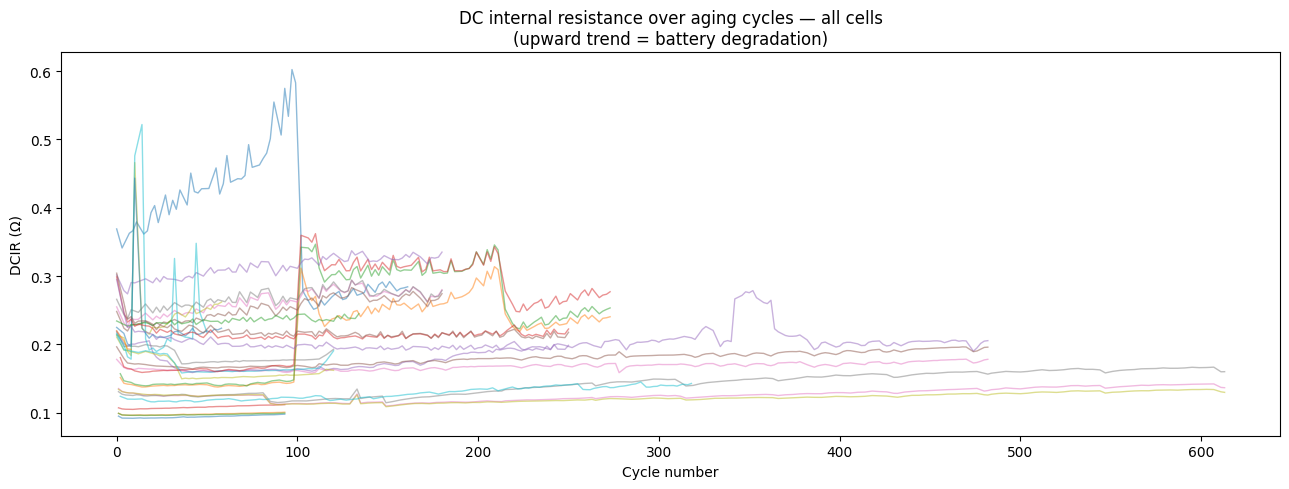

In [9]:
# ── Cell 3: Plot DCIR over cycles for all cells ───────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

for cell_name in dcir_df['cell'].unique():
    cell_data = dcir_df[dcir_df['cell'] == cell_name].sort_values('cycle')
    ax.plot(cell_data['cycle'], cell_data['dcir'],
            alpha=0.5, linewidth=1)

ax.set_xlabel('Cycle number')
ax.set_ylabel('DCIR (Ω)')
ax.set_title('DC internal resistance over aging cycles — all cells\n'
             '(upward trend = battery degradation)')
plt.tight_layout()
plt.savefig('data/dcir_over_cycles.png', dpi=150)
plt.show()
# Expected: lines trending upward as cycle number increases
# If flat or random → loading issue, paste output here

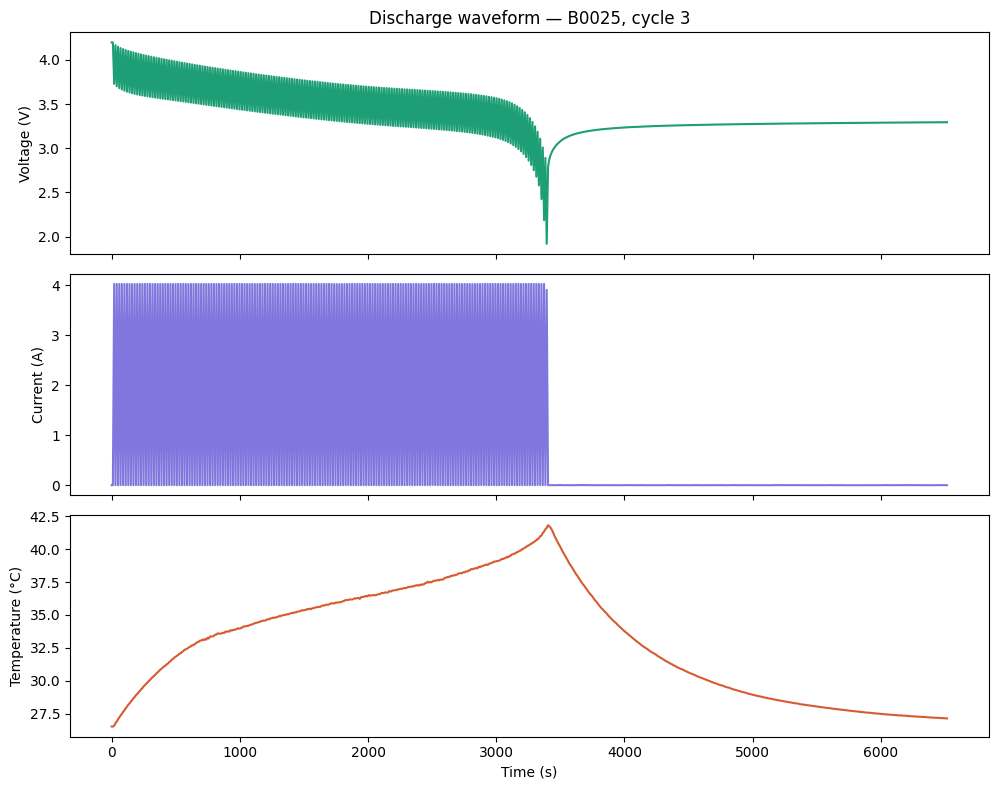

In [10]:
# ── Cell 4: Plot discharge waveform for one cell (V, I, T vs time) ───────────
# Pick first cell that has a discharge cycle with temperature data
plotted = False
for cell_name, battery in all_cells.items():
    if plotted:
        break
    try:
        cycles = battery['cycle'][0]
    except Exception:
        continue

    for i, cycle in enumerate(cycles):
        try:
            if cycle['type'][0] != 'discharge':
                continue
            data  = cycle['data'][0][0]
            V = data['Voltage_measured'].flatten()
            I = data['Current_measured'].flatten()
            T = data['Temperature_measured'].flatten()
            t = data['Time'].flatten()

            if len(V) < 10:
                continue

            fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

            axes[0].plot(t, V, color='#1D9E75', linewidth=1.5)
            axes[0].set_ylabel('Voltage (V)')
            axes[0].set_title(f'Discharge waveform — {cell_name}, cycle {i}')

            axes[1].plot(t, np.abs(I), color='#7F77DD', linewidth=1.5)
            axes[1].set_ylabel('Current (A)')

            axes[2].plot(t, T, color='#D85A30', linewidth=1.5)
            axes[2].set_ylabel('Temperature (°C)')
            axes[2].set_xlabel('Time (s)')

            plt.tight_layout()
            plt.savefig('data/discharge_waveform.png', dpi=150)
            plt.show()
            plotted = True
            break
        except Exception:
            continue


In [11]:
# ── Cell 5: DCIR summary statistics per cell ─────────────────────────────────
dcir_summary = dcir_df.groupby('cell')['dcir'].agg(
    first_cycle='first',
    last_cycle='last',
    mean='mean',
    pct_increase=lambda x: round((x.iloc[-1] - x.iloc[0]) / x.iloc[0] * 100, 1)
                 if x.iloc[0] > 0 else 0
).reset_index()

print('\nDCIR summary — resistance increase over lifetime:')
print(dcir_summary.sort_values('pct_increase', ascending=False).to_string())
# pct_increase shows how much internal resistance grew from first to last cycle
# Higher % = more degradation = matches your SoH findings from Day 1



DCIR summary — resistance increase over lifetime:
     cell  first_cycle  last_cycle      mean  pct_increase
16  B0043     0.156947    0.253273  0.234695          61.4
15  B0042     0.151402    0.240357  0.210979          58.8
17  B0044     0.180530    0.276943  0.250799          53.4
22  B0049     0.213367    0.261850  0.242785          22.7
1   B0006     0.130604    0.159896  0.141962          22.4
3   B0018     0.123820    0.142643  0.128050          15.2
18  B0045     0.301483    0.335043  0.313377          11.1
19  B0046     0.248082    0.274145  0.252930          10.5
20  B0047     0.254815    0.279876  0.263054           9.8
21  B0048     0.265891    0.278859  0.268339           4.9
26  B0053     0.234159    0.244750  0.234932           4.5
7   B0032     0.106970    0.111625  0.108088           4.4
4   B0029     0.094792    0.097656  0.094114           3.0
5   B0030     0.098937    0.100513  0.097919           1.6
0   B0005     0.135169    0.136412  0.126178           0.9
23  B

In [12]:
# ── Cell 6: Overlay DCIR trend with SoH from nasa_processed.csv ──────────────
# This connects your ECE signal analysis back to your ML dataset
nasa_df = pd.read_csv('nasa_processed.csv')

# Pick one cell that exists in both datasets
common_cells = set(dcir_df['cell'].unique()) & \
               set(nasa_df['battery_id'].astype(str).unique())
print(f'\nCells in both DCIR and NASA processed: {common_cells}')

if common_cells:
    cell = list(common_cells)[0]

    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax2 = ax1.twinx()

    # DCIR on left axis
    d = dcir_df[dcir_df['cell'] == cell].sort_values('cycle')
    ax1.plot(d['cycle'], d['dcir'],
             color='#D85A30', label='DCIR (Ω)', linewidth=1.5)
    ax1.set_ylabel('DCIR (Ω)', color='#D85A30')
    ax1.tick_params(axis='y', labelcolor='#D85A30')

    # SoH on right axis
    s = nasa_df[nasa_df['battery_id'].astype(str) == cell]\
        .sort_values('test_id')
    ax2.plot(s['test_id'], s['SoH'],
             color='#1D9E75', label='SoH (%)', linewidth=1.5,
             linestyle='--')
    ax2.set_ylabel('SoH (%)', color='#1D9E75')
    ax2.tick_params(axis='y', labelcolor='#1D9E75')

    ax1.set_xlabel('Cycle / Test ID')
    ax1.set_title(f'DCIR rises as SoH falls — cell {cell}\n'
                  f'(confirms internal resistance as early warning signal)')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

    plt.tight_layout()
    plt.savefig('data/dcir_vs_soh.png', dpi=150)
    plt.show()
else:
    print('No overlapping cells — check battery_id format in nasa_processed.csv')




Cells in both DCIR and NASA processed: set()
No overlapping cells — check battery_id format in nasa_processed.csv


In [13]:
# ── Cell 7: Save DCIR dataset ─────────────────────────────────────────────────
dcir_df.to_csv('data/dcir_all_cells.csv', index=False)
print(f'Saved dcir_all_cells.csv — {dcir_df.shape[0]} rows, '
      f'{dcir_df["cell"].nunique()} cells')

Saved dcir_all_cells.csv — 2655 rows, 30 cells
